In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
import pandas as pd
import numpy as np

dates = pd.date_range('2023-01-01', '2025-12-01', freq='MS')

np.random.seed(42)

df = pd.DataFrame({
    'Month': dates,
    'TV_Spend': np.random.randint(1000, 3000, len(dates)),
    'Digital_Spend': np.random.randint(800, 2500, len(dates)),
    'Search_Spend': np.random.randint(500, 1800, len(dates)),
    'Social_Spend': np.random.randint(300, 1300, len(dates)),
    'Promo_Spend': np.random.randint(400, 2500, len(dates)),
    'Price_Index': np.random.randint(92, 101, len(dates)),
    'Distribution': np.random.randint(85, 99, len(dates)),
    'Competitor_Spend': np.random.randint(1500, 2500, len(dates))
})

df['Holiday_Flag'] = df['Month'].dt.month.isin([10,11,12]).astype(int)

df['Sales'] = (
    5000
    + 2.5*df['TV_Spend']
    + 3*df['Digital_Spend']
    + 1.5*df['Search_Spend']
    + 1.2*df['Social_Spend']
    + 2*df['Promo_Spend']
    - 50*(df['Price_Index']-95)
    + 20*df['Distribution']
    - 0.8*df['Competitor_Spend']
    + 1000*df['Holiday_Flag']
    + np.random.normal(0,500,len(df))
).round()

print(df.head())

       Month  TV_Spend  Digital_Spend  Search_Spend  Social_Spend  \
0 2023-01-01      2126           1547          1455          1112   
1 2023-02-01      2459           1656          1008           364   
2 2023-03-01      1860           2384          1275          1156   
3 2023-04-01      2294           1274           534          1138   
4 2023-05-01      2130           1882           705           820   

   Promo_Spend  Price_Index  Distribution  Competitor_Spend  Holiday_Flag  \
0         2295           98            89              1902             0   
1         1970           92            85              1845             0   
2         1360           92            85              2462             0   
3         1885          100            87              2010             0   
4         1428          100            98              1646             0   

     Sales  
0  23301.0  
1  22769.0  
2  22084.0  
3  19715.0  
4  21523.0  


In [3]:
df.to_csv(r"C:\Users\Mandeep\Downloads\mmmm_dataset.csv", index=False)

In [9]:
from sklearn.linear_model import LinearRegression

X = df[['TV_adstock',
        'Digital_adstock','Search_adstock','Social_adstock','Promo_adstock','Price_Index',
        'Distribution','Competitor_Spend','Holiday_Flag']]

y = df['Sales']

import statsmodels.api as sm

X_sm = sm.add_constant(X)

model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     8.184
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           1.16e-05
Time:                        13:59:56   Log-Likelihood:                -304.26
No. Observations:                  36   AIC:                             628.5
Df Residuals:                      26   BIC:                             644.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2877.0416   9152.325  

In [44]:
def adstock(x, rate):
    result = []
    carryover = 0

    for spend in x:
        carryover = spend + carryover * rate
        result.append(carryover)

    return result

df['TV_adstock'] = adstock(df['TV_Spend'], 0.5)
df['Digital_adstock'] = adstock(df['Digital_Spend'], 0.2)
df['Search_adstock'] = adstock(df['Search_Spend'], 0.2)
df['Social_adstock'] = adstock(df['Social_Spend'], 0.2)
df['Promo_adstock'] = adstock(df['Promo_Spend'], 0.1)

In [45]:

def saturation(x, alpha):
    return x / (alpha + x)

df['TV_sat'] = saturation(df['TV_adstock'], 5000)
df['Digital_sat'] = saturation(df['Digital_adstock'], 3000)
df['Search_sat'] = saturation(df['Search_adstock'], 3000)
df['Social_sat'] = saturation(df['Social_adstock'], 3000)
df['Promo_sat'] = saturation(df['Promo_adstock'], 2000)

X = df[['TV_sat',
        'Digital_sat',
        'Search_sat',
        'Social_sat',
        'Promo_sat',
        'Price_Index',
        'Distribution',
        'Competitor_Spend',
        'Holiday_Flag']]


In [50]:
X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()

coef_dict = model_sm.params.to_dict()
for col in X.columns:
    df[f'{col}_contribution'] = (
        coef_dict[col] * df[col]
    )
    

print(model_sm.params)

const               -7690.728282
TV_sat              11419.692459
Digital_sat         21603.260945
Search_sat          13945.995312
Social_sat          -3468.342105
Promo_sat           16765.515619
Price_Index            24.020879
Distribution           22.215180
Competitor_Spend       -0.182816
Holiday_Flag         -208.559935
dtype: float64


In [51]:
# Contribution columns
contribution_cols = [f'{col}_contribution' for col in X.columns]

# Predicted Sales
df['Predicted_Sales'] = model_sm.predict(X_sm)

# Total contribution
df['Total_Media_Contribution'] = df[contribution_cols].sum(axis=1)

# Base sales (intercept)
df['Base_Sales'] = model_sm.params['const']

# Validation
df['Predicted_Sales_Check'] = (
    df['Base_Sales']
    + df['Total_Media_Contribution']
)

In [52]:
print(df[['Predicted_Sales', 'Predicted_Sales_Check']].head())

   Predicted_Sales  Predicted_Sales_Check
0     19625.044126           19625.044126
1     21768.594505           21768.594505
2     22224.476130           22224.476130
3     20034.024348           20034.024348
4     20791.032228           20791.032228


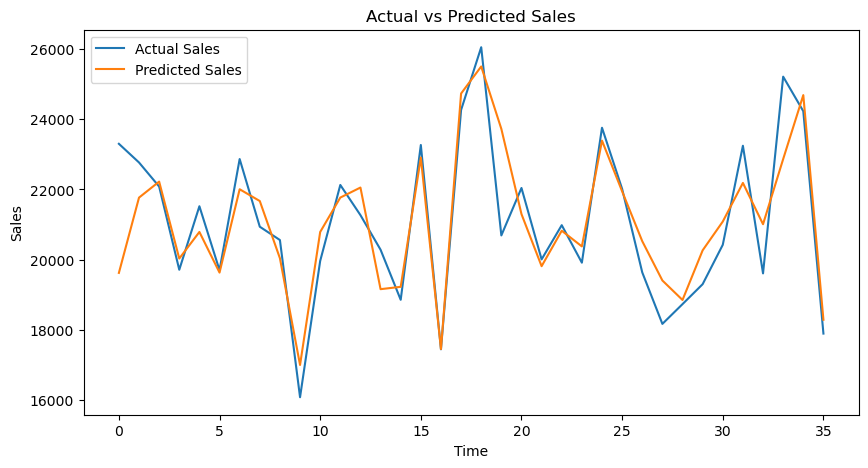

In [53]:
df['Predicted_Sales'] = model_sm.predict(X_sm)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df.index, df['Sales'], label='Actual Sales')
plt.plot(df.index, df['Predicted_Sales'], label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()

plt.show()

In [54]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

r2 = r2_score(df['Sales'], df['Predicted_Sales'])
mape = mean_absolute_percentage_error(
    df['Sales'],
    df['Predicted_Sales']
) * 100

print(f'R²: {r2:.3f}')
print(f'MAPE: {mape:.2f}%')

R²: 0.752
MAPE: 3.71%


In [55]:
# Get coefficients
coef_dict = model_sm.params.to_dict()

# Calculate contribution by variable
contributions = {}

for col in X.columns:
    contributions[col] = (
        coef_dict[col] * df[col]
    ).sum()

# Base sales contribution
base_sales = coef_dict['const'] * len(df)

print(contributions)

{'TV_sat': 177160.3387883242, 'Digital_sat': 307244.9191204332, 'Search_sat': 161383.14531692935, 'Social_sat': -28685.363280646656, 'Promo_sat': 279091.378736352, 'Price_Index': 82751.92965273406, 'Distribution': 72554.778526811, 'Competitor_Spend': -13778.86928302526, 'Holiday_Flag': -1877.0394106206131}


In [61]:
waterfall_data = {
    'Base Sales': base_sales,
    'TV': contributions['TV_sat'],
    'Digital': contributions['Digital_sat'],
    'Search': contributions['Search_sat'],
    'Social': contributions['Social_sat'],
    'Promo': contributions['Promo_sat'],
    'Price': contributions['Price_Index'],
    'Distribution': contributions['Distribution'],
    'Competitor': contributions['Competitor_Spend'],
    'Holiday': contributions['Holiday_Flag']
}

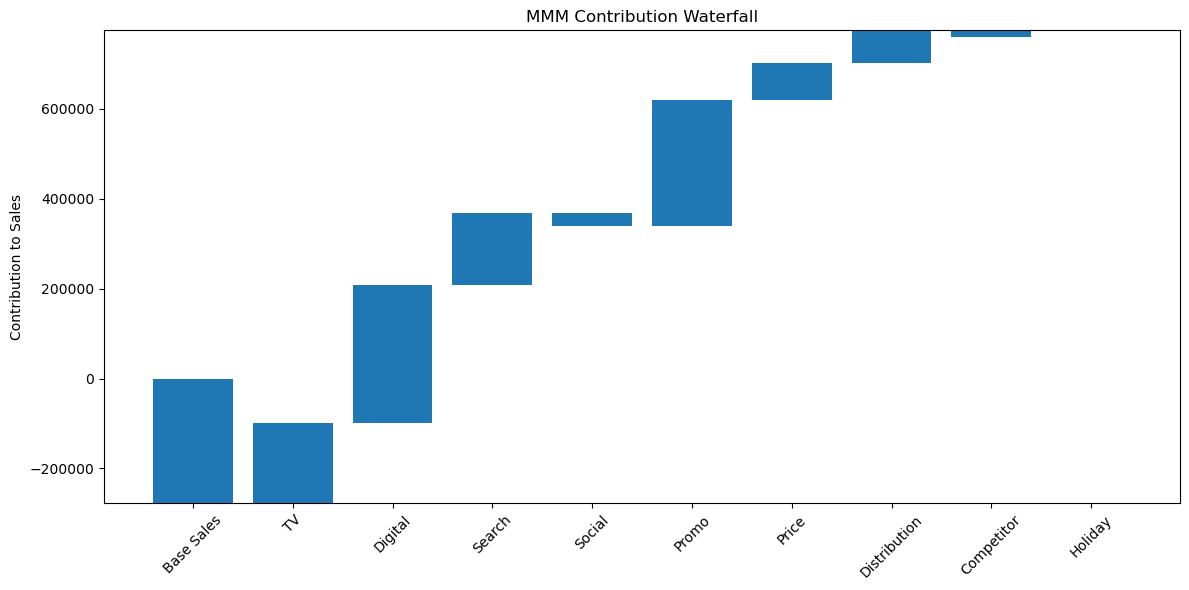

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

wf = pd.Series(waterfall_data)

cumulative = wf.cumsum().shift(fill_value=0)

plt.figure(figsize=(12,6))

plt.bar(
    wf.index,
    wf.values,
    bottom=cumulative
)

plt.title("MMM Contribution Waterfall")
plt.ylabel("Contribution to Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
total_sales = base_sales + sum(contributions.values())

share_df = pd.DataFrame({
    'Channel': waterfall_data.keys(),
    'Contribution': waterfall_data.values()
})

share_df['Contribution_%'] = (
    share_df['Contribution']
    / total_sales
    * 100
)

print(
    share_df.sort_values(
        'Contribution_%',
        ascending=False
    )
)

        Channel   Contribution  Contribution_%
2       Digital  307244.919120       40.481347
5         Promo  279091.378736       36.771950
1            TV  177160.338788       23.341929
3        Search  161383.145317       21.263190
6         Price   82751.929653       10.903059
7  Distribution   72554.778527        9.559524
9       Holiday   -1877.039411       -0.247311
8    Competitor  -13778.869283       -1.815448
4        Social  -28685.363281       -3.779467
0    Base Sales -276866.218167      -36.478772


In [64]:
roi_df = pd.DataFrame({
    'Channel': [
        'TV',
        'Digital',
        'Search',
        'Social',
        'Promo'
    ],
    'Spend': [
        df['TV_Spend'].sum(),
        df['Digital_Spend'].sum(),
        df['Search_Spend'].sum(),
        df['Social_Spend'].sum(),
        df['Promo_Spend'].sum()
    ],
    'Contribution': [
        contributions['TV_sat'],
        contributions['Digital_sat'],
        contributions['Search_sat'],
        contributions['Social_sat'],
        contributions['Promo_sat']
    ]
})

roi_df['ROI'] = (
    roi_df['Contribution']
    / roi_df['Spend']
)

print(roi_df)

   Channel  Spend   Contribution       ROI
0       TV  70271  177160.338788  2.521102
1  Digital  58040  307244.919120  5.293675
2   Search  42025  161383.145317  3.840170
3   Social  26546  -28685.363281 -1.080591
4    Promo  58840  279091.378736  4.743225


In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(
        X.values, i
    )
    for i in range(X.shape[1])
]

print(vif)

           Variable         VIF
0            TV_sat  153.218165
1       Digital_sat   62.269561
2        Search_sat   38.219651
3        Social_sat   24.445215
4         Promo_sat   34.329708
5       Price_Index  480.158984
6      Distribution  452.379178
7  Competitor_Spend   62.183047
8      Holiday_Flag    1.946737
